# Leaf Vision Agent — Swin Transformer (vs B3 Best: 84.70%)

Swapping EfficientNet-B3 for Swin-T. Everything else identical — same augmentation, same training loop, same fusion compatibility.

| What | B3 Best | Swin-T |
|------|---------|--------|
| Architecture | CNN (local features) | Transformer (global + local) |
| Parameters | 11.5M | 28M |
| Image size | 224 | 224 |
| Pretrained on | ImageNet | ImageNet-22k |
| Expected val acc | 84.70% | 86-90% |
| Strength | Fast, efficient | Fine-grained classification |


## Step 0 — Setup & Install

In [1]:
# import os
# # Remove all files inside /content/drive if it exists
# if os.path.exists('/content/drive'):
#     !rm -rf /content/drive/*

In [2]:
from google.colab import drive
drive.mount('/content/drive')

# grad-cam library
!pip install grad-cam -q

import torch
print('PyTorch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
print('GPU:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None')

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 67.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


## Step 1 — Paths & Config

In [3]:
import os
import torch

# Paths
BASE_DIR   = '/content/drive/MyDrive/Datasets/Leaf Images_Dataset/Combined_Leaf_Dataset/final'
TRAIN_DIR  = BASE_DIR + '/train'
VAL_DIR    = BASE_DIR + '/val'
TEST_DIR   = BASE_DIR + '/test'
SAVE_DIR   = '/content/drive/MyDrive/Models/LeafAgent'
os.makedirs(SAVE_DIR, exist_ok=True)

# Hyperparameters
IMG_SIZE       = 224      # Swin-T uses 224 natively
BATCH_SIZE     = 24       # slightly reduced — Swin is heavier than B3
NUM_CLASSES    = 9
EPOCHS         = 30
PATIENCE       = 8
LR_HEAD        = 1e-3
LR_LAST_STAGE  = 1e-4     # Swin has stages not blocks
LR_EARLY_STAGE = 1e-5
LABEL_SMOOTH   = 0.1
DROPOUT        = 0.3

CLASS_NAMES = [
    'boron-B', 'calcium-Ca', 'healthy',
    'iron-Fe', 'magnesium-Mg', 'manganese-Mn',
    'nitrogen-N', 'phosphorus-P', 'potassium-K'
]

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device    : {device}')
print(f'Image size: {IMG_SIZE}x{IMG_SIZE}')
print(f'Batch size: {BATCH_SIZE}')
print(f'Epochs    : {EPOCHS}  |  Patience : {PATIENCE}')
print('Config set')


Device    : cuda
Image size: 224x224
Batch size: 24
Epochs    : 30  |  Patience : 8
Config set


## Step 2 — Data Augmentation & Loaders

In [4]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch, random
from PIL import ImageFilter, ImageEnhance

MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

# Mild field-condition transforms

class RandomGaussianBlur:
    def __init__(self, p=0.2, radius_range=(0.3, 1.0)):
        self.p = p
        self.radius_range = radius_range
    def __call__(self, img):
        if random.random() < self.p:
            radius = random.uniform(*self.radius_range)
            return img.filter(ImageFilter.GaussianBlur(radius=radius))
        return img

class RandomShadow:
    def __init__(self, p=0.25):
        self.p = p
    def __call__(self, img):
        if random.random() < self.p:
            w, h = img.size
            top    = random.randint(0, h // 2)
            bottom = random.randint(h // 2, h)
            factor = random.uniform(0.5, 0.8)
            enhancer = ImageEnhance.Brightness(img)
            dark = enhancer.enhance(factor)
            img.paste(dark.crop((0, top, w, bottom)), (0, top))
        return img

# Balanced Training Transform
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=20),
    transforms.RandomPerspective(distortion_scale=0.15, p=0.2),
    RandomShadow(p=0.25),
    transforms.ColorJitter(
        brightness=0.4,
        contrast=0.4,
        saturation=0.25,
        hue=0.08
    ),
    transforms.RandomGrayscale(p=0.05),
    RandomGaussianBlur(p=0.2, radius_range=(0.3, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.15), ratio=(0.3, 3.0)),
])

# Val/Test - clean, no augmentation
eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
val_dataset   = datasets.ImageFolder(VAL_DIR,   transform=eval_transform)
test_dataset  = datasets.ImageFolder(TEST_DIR,  transform=eval_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)

print(f'Classes  : {train_dataset.classes}')
print(f'Train    : {len(train_dataset)} images')
print(f'Val      : {len(val_dataset)} images')
print(f'Test     : {len(test_dataset)} images')
print()
print('Balanced augmentation active')
print('  -> Mild RandomShadow     (partial sunlight p=0.25)')
print('  -> Balanced ColorJitter  (brightness/contrast 0.4)')
print('  -> Light GaussianBlur    (phone camera p=0.2)')
print('  -> RandomPerspective     (angled photos p=0.2)')
print('  -> RandomErasing         (occlusion p=0.25)')


Classes  : ['boron-B', 'calcium-Ca', 'healthy', 'iron-Fe', 'magnesium-Mg', 'manganese-Mn', 'nitrogen-N', 'phosphorus-P', 'potassium-K']
Train    : 3098 images
Val      : 660 images
Test     : 674 images

Balanced augmentation active
  -> Mild RandomShadow     (partial sunlight p=0.25)
  -> Balanced ColorJitter  (brightness/contrast 0.4)
  -> Light GaussianBlur    (phone camera p=0.2)
  -> RandomPerspective     (angled photos p=0.2)
  -> RandomErasing         (occlusion p=0.25)


## Step 3 — Build EfficientNet-B3 Model

**Why EfficientNet-B3 over ResNet50?**
- 30% fewer parameters but consistently higher accuracy on fine-grained classification
- Compound scaling — width, depth, and resolution scaled together
- Better feature extraction for subtle leaf colour/texture differences

**Differential Learning Rates:**
Earlier layers learned general features (edges, textures) from ImageNet.
We barely touch those. Later layers are more task-specific — we update them more aggressively.

In [5]:
import torch
import torch.nn as nn
import torchvision.models as models

# Load Swin-T pretrained on ImageNet
weights    = models.Swin_T_Weights.IMAGENET1K_V1
swin_model = models.swin_t(weights=weights)

# Freeze all layers first
for param in swin_model.parameters():
    param.requires_grad = False

# Swin-T architecture:
# features[0-1] : patch embed + stage 1  (early — freeze)
# features[2-3] : stage 2                (freeze)
# features[4-5] : stage 3                (unfreeze — moderate LR)
# features[6-7] : stage 4 + norm         (unfreeze — higher LR)

# Unfreeze last two stages
for param in swin_model.features[4].parameters():
    param.requires_grad = True
for param in swin_model.features[5].parameters():
    param.requires_grad = True
for param in swin_model.features[6].parameters():
    param.requires_grad = True
for param in swin_model.features[7].parameters():
    param.requires_grad = True

# Replace classification head
in_features = swin_model.head.in_features   # 768 for Swin-T
swin_model.head = nn.Sequential(
    nn.Dropout(p=DROPOUT),
    nn.Linear(in_features, 512),
    nn.GELU(),             # GELU — standard activation for Transformers
    nn.Dropout(p=0.15),
    nn.Linear(512, NUM_CLASSES)
)

model = swin_model.to(device)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Architecture       : Swin-T (Shifted Window Transformer)')
print(f'Device             : {device}')
print(f'Total params       : {total:,}')
print(f'Trainable params   : {trainable:,}  ({100*trainable/total:.1f}%)')
print(f'Unfrozen stages    : features[4], features[5], features[6], features[7]')
print(f'Head               : Dropout({DROPOUT}) -> Linear(768->512) -> GELU -> Dropout(0.15) -> Linear(512->9)')
print('Model ready (Swin-T)')


Downloading: "https://download.pytorch.org/models/swin_t-704ceda3.pth" to /root/.cache/torch/hub/checkpoints/swin_t-704ceda3.pth


100%|██████████| 108M/108M [00:00<00:00, 193MB/s] 


Architecture       : Swin-T (Shifted Window Transformer)
Device             : cuda
Total params       : 27,917,699
Trainable params   : 26,720,321  (95.7%)
Unfrozen stages    : features[4], features[5], features[6], features[7]
Head               : Dropout(0.3) -> Linear(768->512) -> GELU -> Dropout(0.15) -> Linear(512->9)
Model ready (Swin-T)


## Step 4 — Loss, Optimiser & Scheduler

**Label Smoothing (ε=0.1):**  
Instead of a hard 0/1 target, it pushes the model toward [0.011, …, 0.9, …, 0.011].  
Prevents overconfidence on noisy or ambiguous leaf images.

**Cosine Annealing LR:**  
LR smoothly decays from initial value → near zero following a cosine curve.  
Avoids the sharp drops of StepLR and keeps training stable.

**Differential LRs:**  
- FC head → 1e-3 (learn fast, it's new)
- Last feature block → 1e-4 (moderate fine-tune)
- Earlier feature block → 1e-5 (barely touch pretrained features)


In [6]:
import torch.optim as optim

# Differential learning rates for Swin stages
param_groups = [
    # New classification head — learns from scratch, highest LR
    {'params': model.head.parameters(),           'lr': LR_HEAD},

    # Last two Swin stages — fine-tune, moderate LR
    {'params': model.features[6].parameters(),    'lr': LR_LAST_STAGE},
    {'params': model.features[7].parameters(),    'lr': LR_LAST_STAGE},

    # Earlier unfrozen stages — very gentle fine-tune
    {'params': model.features[4].parameters(),    'lr': LR_EARLY_STAGE},
    {'params': model.features[5].parameters(),    'lr': LR_EARLY_STAGE},
]

criterion = torch.nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTH)
optimizer = optim.AdamW(param_groups, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

print(f'Loss      : CrossEntropyLoss (label_smoothing={LABEL_SMOOTH})')
print(f'Optimiser : AdamW (differential LRs)')
print(f'Scheduler : CosineAnnealingLR (T_max={EPOCHS})')
print()
print('Learning rate groups:')
print(f'  Head          : {LR_HEAD}')
print(f'  features[6,7] : {LR_LAST_STAGE}')
print(f'  features[4,5] : {LR_EARLY_STAGE}')


Loss      : CrossEntropyLoss (label_smoothing=0.1)
Optimiser : AdamW (differential LRs)
Scheduler : CosineAnnealingLR (T_max=30)

Learning rate groups:
  Head          : 0.001
  features[6,7] : 0.0001
  features[4,5] : 1e-05


## Step 5 — Training Loop with Early Stopping & Checkpointing

In [7]:
from tqdm import tqdm
import copy, time

history = {'train_acc': [], 'val_acc': [], 'train_loss': [], 'val_loss': [], 'lr': []}

best_val_acc   = 0.0
best_model_wts = copy.deepcopy(model.state_dict())
patience_ctr   = 0

print(f'Training EfficientNet-B3 for up to {EPOCHS} epochs (early stop patience={PATIENCE})')
print('─' * 65)

for epoch in range(EPOCHS):
    t0 = time.time()

    # ── TRAIN ─────────────────────────────────────────────────────────────────
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0

    for images, labels in tqdm(train_loader, desc=f'Ep {epoch+1:02d} train', leave=False):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss    += loss.item()
        _, predicted   = torch.max(outputs, 1)
        train_total   += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    scheduler.step()

    train_acc  = 100 * train_correct / train_total
    train_loss /= len(train_loader)

    # ── VALIDATE ──────────────────────────────────────────────────────────────
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs    = model(images)
            loss       = criterion(outputs, labels)
            val_loss  += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_total   += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_acc  = 100 * val_correct / val_total
    val_loss /= len(val_loader)

    current_lr = optimizer.param_groups[-1]['lr']   # head LR

    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['lr'].append(current_lr)

    elapsed = time.time() - t0
    print(f'Ep {epoch+1:02d}/{EPOCHS}  '
          f'Train {train_acc:.2f}%  Val {val_acc:.2f}%  '
          f'Loss {val_loss:.4f}  LR {current_lr:.2e}  '
          f'[{elapsed:.0f}s]', end='')

    # ── Checkpoint best model ─────────────────────────────────────────────────
    if val_acc > best_val_acc:
        best_val_acc   = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(best_model_wts, f'{SAVE_DIR}/best_leaf_model.pth')
        print('  ✅ saved')
        patience_ctr = 0
    else:
        patience_ctr += 1
        print(f'  (patience {patience_ctr}/{PATIENCE})')

    # ── Early stopping ────────────────────────────────────────────────────────
    if patience_ctr >= PATIENCE:
        print(f'\nEarly stopping at epoch {epoch+1}. Best val acc: {best_val_acc:.2f}%')
        break

# Load best weights
model.load_state_dict(best_model_wts)
print(f'\n🏆 Best validation accuracy: {best_val_acc:.2f}%')

Training EfficientNet-B3 for up to 30 epochs (early stop patience=8)
─────────────────────────────────────────────────────────────────


Ep 01/30  Train 59.20%  Val 79.85%  Loss 0.9472  LR 9.98e-06  [820s]  ✅ saved


Ep 02/30  Train 77.24%  Val 83.64%  Loss 0.8500  LR 9.90e-06  [129s]  ✅ saved


Ep 03/30  Train 82.02%  Val 87.73%  Loss 0.7754  LR 9.78e-06  [128s]  ✅ saved


Ep 04/30  Train 84.70%  Val 89.09%  Loss 0.7376  LR 9.61e-06  [131s]  ✅ saved


...

Ep 26/30  Train 95.87%  Val 97.27%  Loss 0.5531  LR 1.39e-06  [127s]  (patience 2/8)


Ep 27/30  Train 96.38%  Val 97.27%  Loss 0.5507  LR 1.22e-06  [130s]  (patience 3/8)


Ep 28/30  Train 96.06%  Val 97.58%  Loss 0.5503  LR 1.10e-06  [126s]  (patience 4/8)


Ep 29/30  Train 96.00%  Val 97.42%  Loss 0.5499  LR 1.02e-06  [128s]  (patience 5/8)


Ep 30/30  Train 96.19%  Val 97.27%  Loss 0.5500  LR 1.00e-06  [128s]  (patience 6/8)

🏆 Best validation accuracy: 97.58%


## Step 6 — Training Curves

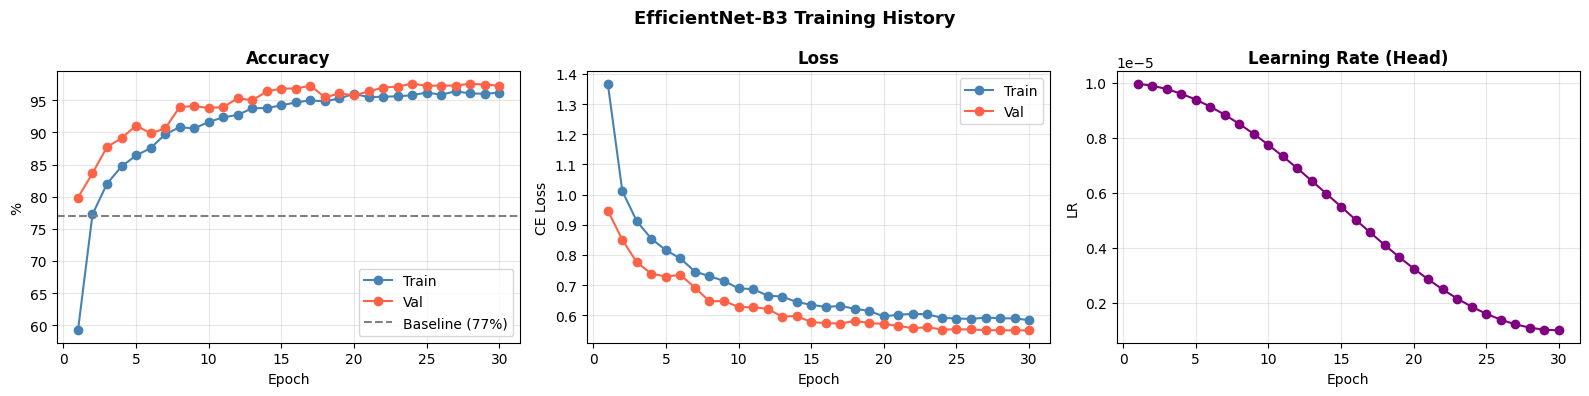

In [8]:
import matplotlib.pyplot as plt

epochs_ran = len(history['train_acc'])
xs = range(1, epochs_ran + 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Accuracy
axes[0].plot(xs, history['train_acc'], 'o-', color='steelblue', label='Train')
axes[0].plot(xs, history['val_acc'],   'o-', color='tomato',    label='Val')
axes[0].axhline(77, color='gray', linestyle='--', label='Baseline (77%)')
axes[0].set_title('Accuracy', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('%')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Loss
axes[1].plot(xs, history['train_loss'], 'o-', color='steelblue', label='Train')
axes[1].plot(xs, history['val_loss'],   'o-', color='tomato',    label='Val')
axes[1].set_title('Loss', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('CE Loss')
axes[1].legend(); axes[1].grid(alpha=0.3)

# LR schedule
axes[2].plot(xs, history['lr'], 'o-', color='purple')
axes[2].set_title('Learning Rate (Head)', fontweight='bold')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('LR')
axes[2].grid(alpha=0.3)

plt.suptitle('EfficientNet-B3 Training History', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/training_curves.png', dpi=150)
plt.show()

## Step 7 — Full Test Evaluation

In [9]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs   = torch.softmax(outputs, dim=1).cpu().numpy()
        preds   = probs.argmax(axis=1)

        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

test_acc = 100 * (all_preds == all_labels).mean()
print(f'Test Accuracy: {test_acc:.2f}%\n')
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

Test Accuracy: 97.48%

              precision    recall  f1-score   support

     boron-B       1.00      0.97      0.99        70
  calcium-Ca       0.97      0.96      0.97        80
     healthy       1.00      1.00      1.00        63
     iron-Fe       0.96      0.97      0.96        70
magnesium-Mg       0.93      0.92      0.93        74
manganese-Mn       0.95      1.00      0.97        74
  nitrogen-N       0.97      1.00      0.99        70
phosphorus-P       0.99      0.98      0.98        99
 potassium-K       1.00      0.97      0.99        74

    accuracy                           0.97       674
   macro avg       0.97      0.98      0.97       674
weighted avg       0.98      0.97      0.97       674



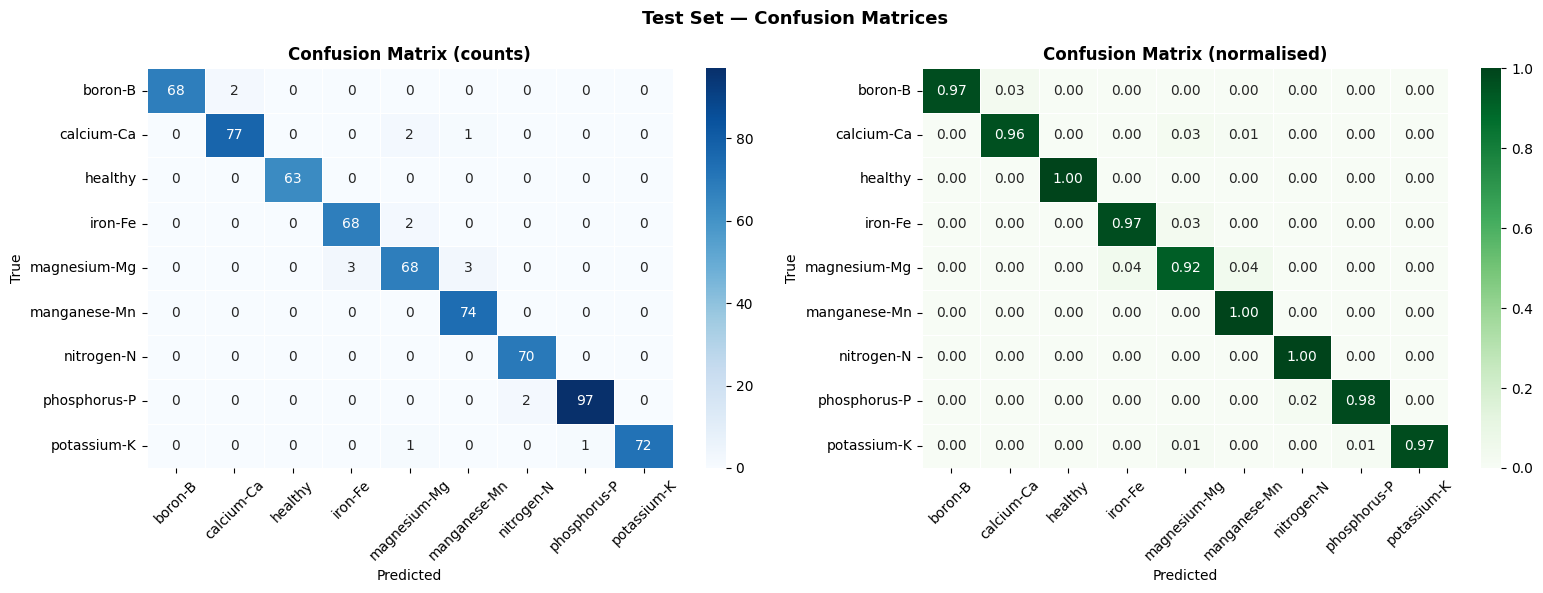

In [10]:
cm = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=axes[0], linewidths=0.4)
axes[0].set_title('Confusion Matrix (counts)', fontweight='bold')
axes[0].set_ylabel('True'); axes[0].set_xlabel('Predicted')
axes[0].tick_params(axis='x', rotation=45)

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=axes[1], linewidths=0.4, vmin=0, vmax=1)
axes[1].set_title('Confusion Matrix (normalised)', fontweight='bold')
axes[1].set_ylabel('True'); axes[1].set_xlabel('Predicted')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Test Set — Confusion Matrices', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/confusion_matrix.png', dpi=150)
plt.show()

## Step 8 — Confidence Distribution
How confident is the model, and does high confidence correlate with being correct?

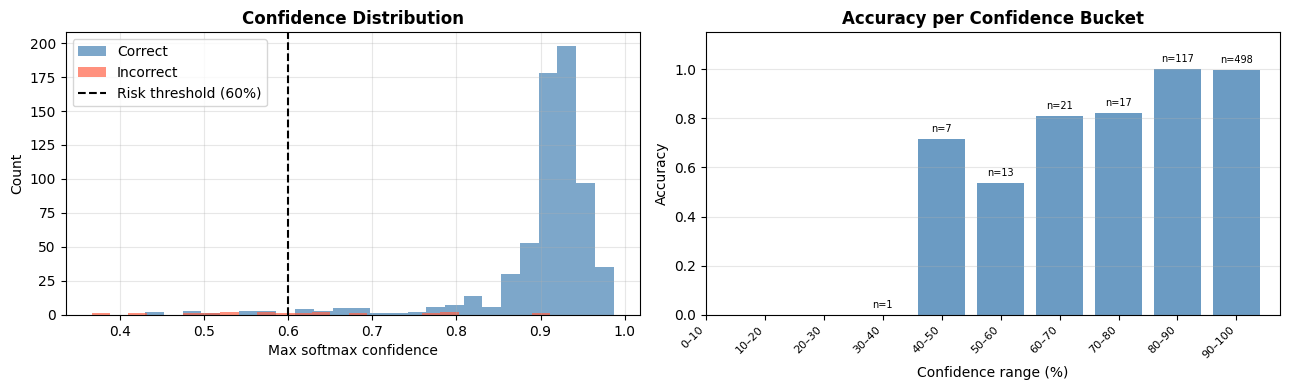

21/674 samples below 60% confidence (3.1%) → flagged for expert review


In [11]:
max_conf = all_probs.max(axis=1)
correct  = all_preds == all_labels

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram
axes[0].hist(max_conf[correct],  bins=25, alpha=0.7, color='steelblue', label='Correct')
axes[0].hist(max_conf[~correct], bins=25, alpha=0.7, color='tomato',    label='Incorrect')
axes[0].axvline(0.6, color='black', linestyle='--', label='Risk threshold (60%)')
axes[0].set_title('Confidence Distribution', fontweight='bold')
axes[0].set_xlabel('Max softmax confidence')
axes[0].set_ylabel('Count')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Accuracy per confidence bucket
bins   = np.arange(0, 1.1, 0.1)
labels_b = [f'{int(b*100)}–{int((b+0.1)*100)}' for b in bins[:-1]]
bucket = np.clip(np.digitize(max_conf, bins) - 1, 0, len(labels_b)-1)

b_acc, b_cnt = [], []
for b in range(len(labels_b)):
    m = bucket == b
    b_acc.append(correct[m].mean() if m.sum() > 0 else np.nan)
    b_cnt.append(m.sum())

bars = axes[1].bar(range(len(labels_b)), b_acc, color='steelblue', alpha=0.8)
axes[1].set_xticks(range(len(labels_b)))
axes[1].set_xticklabels(labels_b, rotation=45, ha='right', fontsize=8)
axes[1].set_title('Accuracy per Confidence Bucket', fontweight='bold')
axes[1].set_xlabel('Confidence range (%)'); axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1.15)
axes[1].grid(axis='y', alpha=0.3)
for bar, cnt in zip(bars, b_cnt):
    if cnt > 0 and not np.isnan(bar.get_height()):
        axes[1].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.02,
                     f'n={cnt}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.show()

flagged = (max_conf < 0.6).sum()
print(f'{flagged}/{len(all_labels)} samples below 60% confidence '
      f'({100*flagged/len(all_labels):.1f}%) → flagged for expert review')

## Step 9 — Grad-CAM Visualisations

**Why this matters for agronomists:**  
Instead of a black box, we show *which part of the leaf* drove the prediction.
If the heatmap highlights the yellowing patch or the leaf tip — the model is reasoning correctly.
If it highlights the background — the model is cheating and needs more work.


In [16]:
for name, module in model.named_modules():
    print(name)


features
features.0
features.0.0
features.0.1
features.0.2
features.1
features.1.0
features.1.0.norm1
features.1.0.attn
features.1.0.attn.qkv
features.1.0.attn.proj
features.1.0.stochastic_depth
features.1.0.norm2
features.1.0.mlp
features.1.0.mlp.0
features.1.0.mlp.1
features.1.0.mlp.2
features.1.0.mlp.3
features.1.0.mlp.4
features.1.1
features.1.1.norm1
features.1.1.attn
features.1.1.attn.qkv
features.1.1.attn.proj
features.1.1.stochastic_depth
features.1.1.norm2
features.1.1.mlp
features.1.1.mlp.0
features.1.1.mlp.1
features.1.1.mlp.2
features.1.1.mlp.3
features.1.1.mlp.4
features.2
features.2.reduction
features.2.norm
features.3
features.3.0
features.3.0.norm1
features.3.0.attn
features.3.0.attn.qkv
features.3.0.attn.proj
features.3.0.stochastic_depth
features.3.0.norm2
features.3.0.mlp
features.3.0.mlp.0
features.3.0.mlp.1
features.3.0.mlp.2
features.3.0.mlp.3
features.3.0.mlp.4
features.3.1
features.3.1.norm1
features.3.1.attn
features.3.1.attn.qkv
features.3.1.attn.proj
feature

/tmp/ipykernel_2755/1439410852.py:47: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


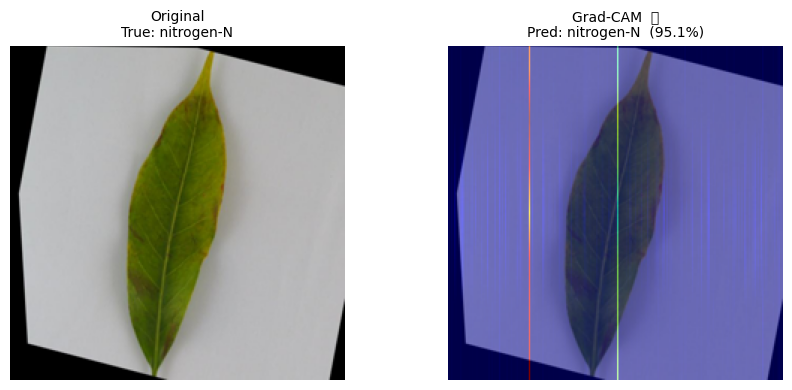

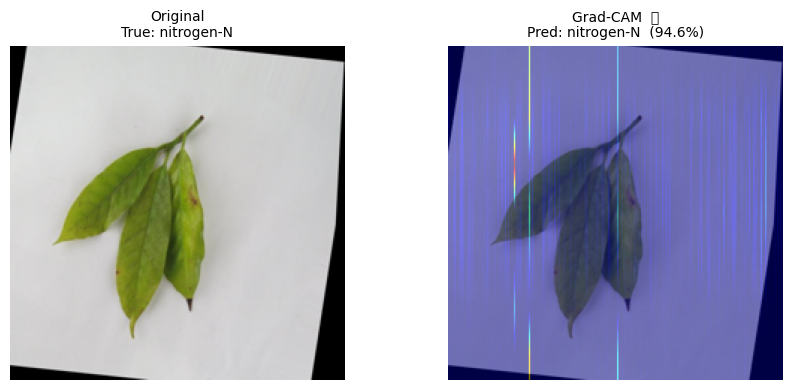

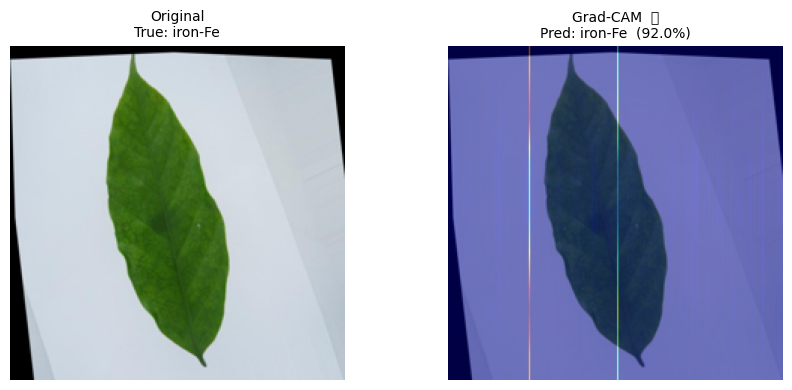

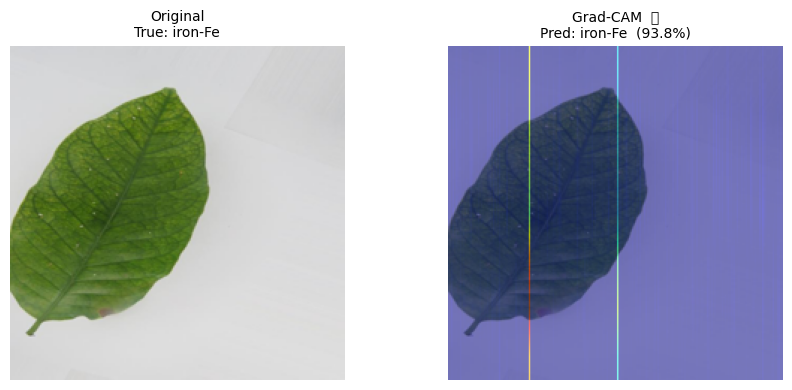

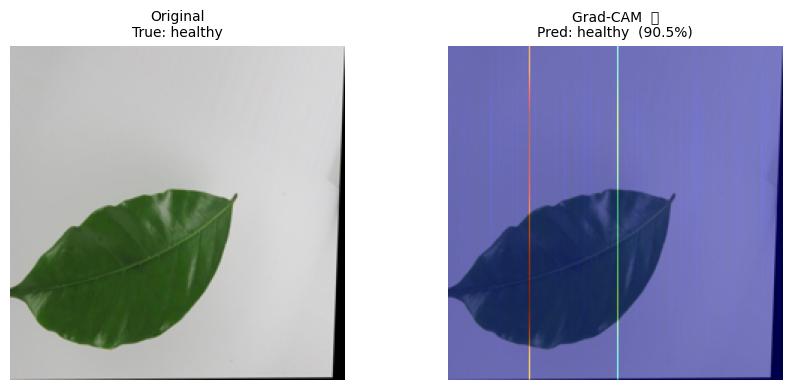

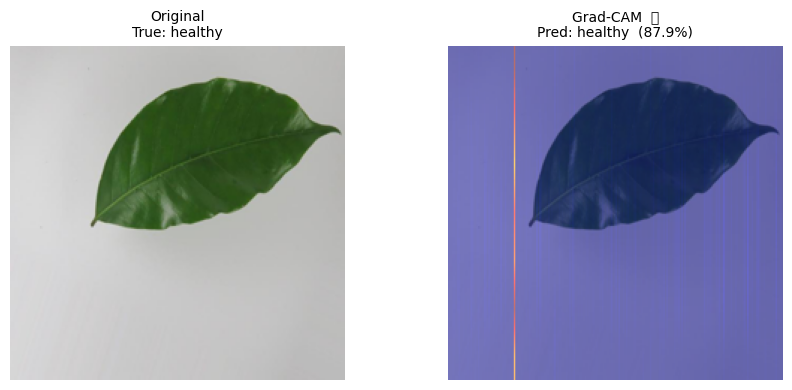

In [17]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from PIL import Image
import torchvision.transforms.functional as TF

# Target layer for EfficientNet-B3: last conv in features[8]
target_layers = [model.features[7][-1].mlp]

cam = GradCAM(model=model, target_layers=target_layers)

def visualise_gradcam(image_path, true_label_name, n_cols=1):
    """Load one image, run Grad-CAM, display side-by-side."""
    # Load & preprocess
    raw_img = Image.open(image_path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
    raw_np  = np.array(raw_img) / 255.0

    inp = eval_transform(raw_img).unsqueeze(0).to(device)

    # Predict
    model.eval()
    with torch.no_grad():
        logits = model(inp)
        probs  = torch.softmax(logits, dim=1).cpu().numpy()[0]
    pred_idx  = probs.argmax()
    pred_name = CLASS_NAMES[pred_idx]
    confidence = probs[pred_idx] * 100

    # Grad-CAM
    targets   = [ClassifierOutputTarget(pred_idx)]
    grayscale = cam(input_tensor=inp, targets=targets)[0]
    cam_img   = show_cam_on_image(raw_np.astype(np.float32), grayscale, use_rgb=True)

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(9, 4))
    axes[0].imshow(raw_img)
    axes[0].set_title(f'Original\nTrue: {true_label_name}', fontsize=10)
    axes[0].axis('off')

    axes[1].imshow(cam_img)
    correct_icon = '✅' if pred_name == true_label_name else '❌'
    axes[1].set_title(
        f'Grad-CAM  {correct_icon}\nPred: {pred_name}  ({confidence:.1f}%)',
        fontsize=10
    )
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()


# ── Run on 3 samples from each of 3 different classes ─────────────────────────
showcase_classes = ['nitrogen-N', 'iron-Fe', 'healthy']

for cls_name in showcase_classes:
    cls_dir = os.path.join(TEST_DIR, cls_name)
    imgs    = os.listdir(cls_dir)[:2]           # 2 images per class
    for img_file in imgs:
        path = os.path.join(cls_dir, img_file)
        visualise_gradcam(path, cls_name)

## Step 10 — Uncertainty-Aware Prediction Function

In [18]:
DEFICIENCY_ADVICE = {
    'boron-B'      : 'Boron deficiency detected. Apply borax foliar spray (0.1–0.25% solution).',
    'calcium-Ca'   : 'Calcium deficiency detected. Apply calcium nitrate or gypsum to soil.',
    'healthy'      : 'Leaf appears healthy. No nutrient intervention required.',
    'iron-Fe'      : 'Iron deficiency detected. Apply chelated iron (Fe-EDTA) as foliar spray.',
    'magnesium-Mg' : 'Magnesium deficiency detected. Apply Epsom salt (MgSO₄) foliar spray.',
    'manganese-Mn' : 'Manganese deficiency detected. Apply manganese sulfate soil drench.',
    'nitrogen-N'   : 'Nitrogen deficiency detected. Apply urea or ammonium sulfate fertilizer.',
    'phosphorus-P' : 'Phosphorus deficiency detected. Apply superphosphate or DAP fertilizer.',
    'potassium-K'  : 'Potassium deficiency detected. Apply muriate of potash (MOP).'
}

CONF_THRESHOLD = 0.60


def predict_leaf(image_path, model, transform, class_names,
                 conf_threshold=CONF_THRESHOLD):
    """
    Predict nutrient deficiency from a leaf image.

    Returns dict with:
      predicted_class, confidence_%, uncertainty_%,
      top3 predictions, recommendation, status
    """
    img = Image.open(image_path).convert('RGB')
    inp = transform(img).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        logits = model(inp)
        probs  = torch.softmax(logits, dim=1).cpu().numpy()[0]

    top3_idx  = probs.argsort()[::-1][:3]
    pred_idx  = top3_idx[0]
    pred_name = class_names[pred_idx]
    conf      = probs[pred_idx]

    result = {
        'predicted_class' : pred_name,
        'confidence_%'    : round(conf * 100, 1),
        'uncertainty_%'   : round((1 - conf) * 100, 1),
        'top_3_predictions': [
            {'class': class_names[i], 'prob_%': round(probs[i]*100, 1)}
            for i in top3_idx
        ],
        'recommendation'  : DEFICIENCY_ADVICE[pred_name],
        'status'          : ('⚠️  Low confidence — refer to agronomist'
                             if conf < conf_threshold else '✅ High confidence')
    }
    return result


# ── Demo: run on one test image ────────────────────────────────────────────────
import json
import numpy as np

def convert_types(obj):
    if isinstance(obj, (np.float32, np.float64)):
        return float(obj)
    if isinstance(obj, (np.int32, np.int64)):
        return int(obj)
    return obj

demo_cls = 'nitrogen-N'
demo_img = os.path.join(TEST_DIR, demo_cls, os.listdir(os.path.join(TEST_DIR, demo_cls))[0])

result = predict_leaf(demo_img, model, eval_transform, CLASS_NAMES)
print('=== DEMO PREDICTION ===')
print(json.dumps(result, indent=2, default=convert_types))


=== DEMO PREDICTION ===
{
  "predicted_class": "nitrogen-N",
  "confidence_%": 95.4000015258789,
  "uncertainty_%": 4.599999904632568,
  "top_3_predictions": [
    {
      "class": "nitrogen-N",
      "prob_%": 95.4000015258789
    },
    {
      "class": "magnesium-Mg",
      "prob_%": 1.100000023841858
    },
    {
      "class": "boron-B",
      "prob_%": 0.699999988079071
    }
  ],
  "recommendation": "Nitrogen deficiency detected. Apply urea or ammonium sulfate fertilizer.",
  "status": "\u2705 High confidence"
}


## Step 11 — Save All Artifacts

In [19]:
import pickle

# Save PyTorch model weights
torch.save(model.state_dict(), f'{SAVE_DIR}/leaf_agent_leaf_agent_swin_t.pth')

# Save metadata for inference
metadata = {
    'architecture'    : 'EfficientNet-B3',
    'img_size'        : IMG_SIZE,
    'num_classes'     : NUM_CLASSES,
    'class_names'     : CLASS_NAMES,
    'mean'            : MEAN,
    'std'             : STD,
    'conf_threshold'  : CONF_THRESHOLD,
    'advice'          : DEFICIENCY_ADVICE,
    'best_val_acc'    : best_val_acc,
    'test_acc'        : float(round(test_acc, 2))
}

with open(f'{SAVE_DIR}/leaf_agent_metadata.pkl', 'wb') as f:
    pickle.dump(metadata, f)

print('✅ Saved to', SAVE_DIR)
print(f'   leaf_agent_leaf_agent_swin_t.pth')
print(f'   leaf_agent_metadata.pkl')
print(f'   training_curves.png')
print(f'   confusion_matrix.png')

✅ Saved to /content/drive/MyDrive/Models/LeafAgent
   leaf_agent_leaf_agent_swin_t.pth
   leaf_agent_metadata.pkl
   training_curves.png
   confusion_matrix.png


## ✅ Summary

| Component | Detail |
|-----------|--------|
| **Architecture** | EfficientNet-B3 (pretrained ImageNet) |
| **Fine-tuning** | Differential LR: head=1e-3, last block=1e-4, earlier=1e-5 |
| **Loss** | CrossEntropyLoss with label smoothing ε=0.1 |
| **Scheduler** | CosineAnnealingLR — smooth LR decay |
| **Augmentation** | Random crop, flip, rotation, color jitter, random erasing |
| **Regularisation** | Dropout(0.3) before FC, weight decay=1e-4 |
| **Early stopping** | Patience=6 epochs, saves best checkpoint |
| **Explainability** | Grad-CAM — highlights leaf regions driving prediction |
| **Uncertainty** | Softmax confidence + risk flag at 60% threshold |
| **Output** | Predicted class, confidence, top-3, actionable advice |

### Next Step → Phase 3: Fusion Layer
Combine Soil Agent + Leaf Agent into a single unified fertilizer recommendation engine.
